#  **Introduction to Machine Learning Phase 2**

Thông tin các thành viên:

| Mã sinh viên | Họ và Tên        |
|--------------|------------------|
| 22120071     | Phan Bá Đức      |
| 22120078     | Nguyễn Bá Duy    |
| 22120182     | Đặng Duy Lân     |


**Tìm hiểu về dữ liệu**

| Thuộc tính                     | Mô tả                                                                                  | Kích thước                    |
|----------------------------------|---------------------------------------------------------------------------------------|------------------------------|
| **vid_id**                       | YouTube video ID liên quan đến mẫu dữ liệu này                                       | (n_sample, 1)               |
| **start_time_seconds_youtube_clip** | Thời điểm bắt đầu của đoạn audio trong video YouTube (tính bằng giây)               |(n_sample, 1)            |
| **end_time_seconds_youtube_clip**   | Thời điểm kết thúc của đoạn audio trong video YouTube (tính bằng giây)              |  (n_sample, 1)            |
| **audio_embedding**              | Đặc trưng âm thanh theo từng frame, giảm chiều xuống còn 128 chiều bằng VGGish       | (n_sample,frame, 128)              |
| **is_turkey**                   | Nhãn mục tiêu: 1 nếu đoạn audio chứa tiếng gà tây, 0 nếu không, dựa trên ontology AudioSet | Số thực (n_sample, 1)              |



## **1. Import thư viện và đọc và phân tích dữ liệu**

In [1]:
import json
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.metrics import confusion_matrix, classification_report, precision_score, recall_score, f1_score, roc_auc_score, accuracy_score, roc_curve

from sklearn.model_selection import KFold
import numpy as np
from itertools import product
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import time

In [2]:
# Tải dữ liệu
# with open('data/train.json', 'r') as f:
with open('train.json', 'r') as f:
    data = json.load(f)

In [3]:
# Chuyển qua dataframe
df = pd.DataFrame(data)

print("Số lượng mẫu:", len(df))
print('Kiểm tra missing values:', df.isnull().values.any())

Số lượng mẫu: 1195
Kiểm tra missing values: False


In [4]:
def extract_info(data):
    '''
    Hàm này trích xuất thông tin từ dữ liệu JSON

    param
        data: Dữ liệu JSON
    return: Một dictionary chứa thông tin về video

    vid_id: ID của video
    is_turkey: Nhãn (1/0)
    frame: Số lượng frame trong mẫu dữ liệu
    dimension: Kích thước của các embedding âm thanh
    duration: Thời gian của video (tính bằng giây) = end_time_seconds_youtube_clip - start_time_seconds_youtube_clip
    '''
    audio_embeddings = data['audio_embedding']

    return {
        'vid_id': data['vid_id'],
        'is_turkey': data['is_turkey'],
        'frame': len(audio_embeddings),
        'dimension': set(len(embedding) for embedding in audio_embeddings),
        'duration': data['end_time_seconds_youtube_clip'] - data['start_time_seconds_youtube_clip']
    }

df = pd.DataFrame([extract_info(item) for item in data])

In [5]:
print('Số lượng mẫu trong dữ liệu là: ', len(df))
print('Số lượng video duy nhất trong dữ liệu là: ',df['vid_id'].nunique())
print('Thông tin mô tả dữ liệu:')
df.describe().T

Số lượng mẫu trong dữ liệu là:  1195
Số lượng video duy nhất trong dữ liệu là:  1195
Thông tin mô tả dữ liệu:


,count,mean,std,min,25%,50%,75%,max
is_turkey,1195.0,0.410879,0.492199,0.0,0.0,0.0,1.0,1.0
frame,1195.0,9.870293,0.730351,2.0,10.0,10.0,10.0,10.0
duration,1195.0,9.928033,0.621913,2.0,10.0,10.0,10.0,10.0


In [6]:
print('Thống kê số lượng nhãn is_turkey:')
df['is_turkey'].value_counts()

Thống kê số lượng nhãn is_turkey:


,count
is_turkey,
0,704
1,491


In [7]:
print('Kiểm tra các frame có cùng số lượng dimension hay không:')
set().union(*df['dimension'])

Kiểm tra các frame có cùng số lượng dimension hay không:


{128}

=> Các frame chỉ có một số lượng dimension duy nhất, đó là 128.

### **Ý tưởng giải quyết vấn đề:**
#### **Cho dữ liệu:**
- Thuộc tính **audio_embedding và is_turkey** được giữa lại để đào tạo mô hình và loại bỏ các thuộc tính còn lại vì không mang ý nhiều ý nghĩa.
- Vấn đề xảy ra ở audio_embedding như đã phân tích ở trên có kích thước là (n_sample,frame, 128) khi thuộc tính is_turkey chỉ có (n_sample,1). Hơn nữa, số lượng frame là khác nhau ở các mỗi mẫu, điều này làm mất đi cân bằng số lượng giá trị. Phương án giải quyết:
    - Làm phẳng toàn bộ (frame, 128) ở mỗi mẫu, nghĩa là (n_sample,frame, 128) -> (n_sample,frame * 128), Nếu số lượng frame khác nhau thì lấp đầy toàn bộ bằng số 0. đảm bảo cùng số lượng phần tử ở mỗi mẫu.

#### **Cho việc xây dựng mô hình:**
- Dữ liệu từ file train.json chỉ có 1195 mẫu, tiến hành chia ra 2 tập là train(80%) và validation (20%)
- Số lớp của dữ liệu là 2 và phân bổ 0 : 704 mẫu, 1 : 491 mẫu. Có sự mất cân bằng rất nhỏ, không ảnh hưởng nhiều.
- Dùng Grid Search để tìm siêu tham số cho mô hình (số tầng ẩn, số lượng nơ-ron mỗi tầng), dựa trên thang đo Accuracy để đánh giá

## Kiểm tra cấu hình phần cứng

In [8]:
# Kiểm tra có GPU không
gpu_available = torch.cuda.is_available()
print(f"GPU có sẵn: {gpu_available}")

# Nếu có GPU, sử dụng nó, nếu không thì sử dụng CPU
device = torch.device("cuda" if gpu_available else "cpu")

if gpu_available:
    # Số lượng GPU
    num_gpus = torch.cuda.device_count()
    print(f"Số GPU: {num_gpus}")

    # Tên GPU
    for i in range(num_gpus):
        gpu_name = torch.cuda.get_device_name(i)
        print(f"GPU {i}: {gpu_name}")

    # ID GPU mặc định
    default_gpu = torch.cuda.current_device()
    print(f"ID GPU mặc định: {default_gpu}")

    torch.cuda.empty_cache()  # Xóa bộ nhớ cache trước khi đo
    print(f"Bộ nhớ GPU đã phân bổ trước khi huấn luyện: {torch.cuda.memory_allocated(device) / 1024**2:.2f} MB")
    print(f"Bộ nhớ GPU đã lưu trữ trước khi huấn luyện: {torch.cuda.memory_reserved(device) / 1024**2:.2f} MB")

GPU có sẵn: True
Số GPU: 1
GPU 0: Tesla T4
ID GPU mặc định: 0
Bộ nhớ GPU đã phân bổ trước khi huấn luyện: 0.00 MB
Bộ nhớ GPU đã lưu trữ trước khi huấn luyện: 0.00 MB


## Khai báo các lớp

In [9]:
# Lớp Dataset cho dữ liệu train
class AudioDataset(Dataset):
    def __init__(self, data, T_max=None):
        '''
        Hàm khởi tạo cho lớp AudioDataset
        :param
            data: Dữ liệu đầu vào, mỗi phần tử là một dictionary chứa thông tin về video
            T_max: Số lượng frame tối đa cho mỗi mẫu. Nếu không cung cấp, sẽ lấy giá trị lớn nhất từ dữ liệu.
        '''
        self.data = data
        self.T_max = T_max if T_max is not None else max(len(sample['audio_embedding']) for sample in data)

        # Tiền xử lý dữ liệu: padding các embedding âm thanh để đảm bảo chúng có cùng kích thước
        for sample in data:
            embedding = sample['audio_embedding']
            len_emb = len(embedding)
            # Nếu số lượng frame của một mẫu nhỏ hơn T_max, sẽ thêm padding bằng 0
            if len_emb < self.T_max:
                padding = [[0] * 128] * (self.T_max - len_emb)
                embedding.extend(padding)

            # Chuẩn hóa dữ liệu: chuyển đổi embedding thành tensor và chia cho 255.0 để đưa về khoảng [0, 1]
            feature = torch.tensor(embedding, dtype=torch.float32) / 255.0

            # Lưu trữ feature đã được flatten vào sample
            sample['feature'] = feature.flatten()

    # Hàm trả về số lượng mẫu trong dataset
    def __len__(self):
        return len(self.data)

    # Hàm trả về một mẫu dữ liệu theo chỉ số idx
    def __getitem__(self, idx):
        sample = self.data[idx]
        return (sample['feature'],
                torch.tensor(sample['is_turkey'], dtype=torch.float32),
                sample['vid_id'])

# Lớp Dataset cho dữ liệu test, vì tập test không có nhãn is_turkey, nên phải xây dựng lớp khác để chỉ trả về feature và vid_id
class TestDataset(Dataset):
    def __init__(self, data, T_max):
        self.data = data
        self.T_max = T_max

        for sample in data:
            embedding = sample['audio_embedding']
            len_emb = len(embedding)
            if len_emb < self.T_max:
                padding = [[0] * 128] * (self.T_max - len_emb)
                embedding.extend(padding)
            feature = torch.tensor(embedding, dtype=torch.float32) / 255.0
            sample['feature'] = feature.flatten()

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        sample = self.data[idx]
        return (sample['feature'], sample['vid_id'])

## Xây dựng mô hình MLP

In [10]:
class SimpleMLP(nn.Module):
    def __init__(self, input_size, hidden_sizes):
        '''
        Hàm khởi tạo cho mô hình MLP
        :param
            input_size: Kích thước đầu vào của mô hình (số lượng đặc trưng đầu vào)
            hidden_sizes: Danh sách các kích thước của các lớp ẩn
        '''
        super(SimpleMLP, self).__init__()
        # Khởi tạo một danh sách rỗng để lưu các lớp mạng trước khi xếp thành chuỗi.
        layers = []
        in_size = input_size
        # Tạo các lớp ẩn dựa trên kích thước đã cho
        # Mỗi lớp bao gồm một lớp Linear, BatchNorm1d, ReLU và Dropout
        for out_size in hidden_sizes:
            layers.append(nn.Linear(in_size, out_size))
            layers.append(nn.BatchNorm1d(out_size))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(0.3))
            in_size = out_size
        # Lớp đầu ra cuối cùng, chỉ có một đầu ra
        layers.append(nn.Linear(in_size, 1))
        # Tạo một mô-đun tuần tự từ danh sách layers, cho phép truyền dữ liệu qua các lớp theo thứ tự.
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

In [11]:
dataset = AudioDataset(data)
T_max = dataset.T_max
input_size = T_max * 128
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)


# Định nghĩa không gian tham số cho Grid Search
num_layers_options = [2, 3, 4]  # Số tầng ẩn
hidden_size_options = [64, 128, 256, 512]  # Kích thước tầng ẩn
learning_rates = [1e-3]  # Sử dụng 1 learning rate vì ta dùng optimizer là Adam có khả năng tự điều chỉnh LR
num_epochs = 100  # Số epoch tối đa
patience = 10  # Early stopping: dừng nếu không cải thiện sau 10 epoch

# Tính tổng số vòng lặp thử nghiệm
total_trials = sum(len(hidden_size_options)**num_layers for num_layers in num_layers_options) * len(learning_rates)

In [12]:
print('Tổng số vòng lặp thử nghiệm:', total_trials)

Tổng số vòng lặp thử nghiệm: 336


### Grid Search

In [13]:
# Grid Search
best_acc = 0 # Lưu accuracy tốt nhất
best_config = None # Lưu cấu hình tốt nhất
best_model_state = None # Lưu trạng thái mô hình tốt nhất
trial_count = 0 # Đếm số lượng vòng lặp thử nghiệm
peak_memories = []  # Danh sách lưu trữ bộ nhớ đỉnh của mỗi thử nghiệm
configs = []  # Danh sách lưu trữ cấu hình
best_acc_list = []  # Danh sách lưu trữ accuracy tốt nhất cho mỗi cấu hình

# Đặt lại bộ nhớ đỉnh trước khi huấn luyện
if torch.cuda.is_available():
    torch.cuda.reset_peak_memory_stats(device)

start_time = time.time()
for num_layers in num_layers_options:
    # Tạo tất cả tổ hợp kích thước tầng ẩn cho số tầng hiện tại
    hidden_sizes_combinations = list(product(hidden_size_options, repeat=num_layers))

    for hidden_sizes_option in hidden_sizes_combinations:
        hidden_sizes = list(hidden_sizes_option)  # Chuyển thành list
        model = SimpleMLP(input_size=input_size, hidden_sizes=hidden_sizes).to(device)
        loss_fn = nn.BCEWithLogitsLoss()

        for lr in learning_rates:
            trial_count += 1
            optimizer = torch.optim.Adam(model.parameters(), lr=lr)

            best_local_acc = 0  # Lưu accuracy tốt nhất cho mỗi cấu hình

            # Lưu trữ cấu hình hiện tại
            # configs.append(f"{hidden_sizes}, lr={lr}")
            configs.append({'hidden_sizes': hidden_sizes, 'lr': lr})

            for epoch in range(num_epochs):
                model.train()

                for batch in train_loader:
                    x, y, _ = batch
                    x, y = x.to(device), y.to(device)
                    optimizer.zero_grad()
                    output = model(x)
                    loss = loss_fn(output.squeeze(), y)
                    loss.backward()
                    optimizer.step()

                model.eval()
                val_preds, val_labels = [], []
                with torch.no_grad():
                    for batch in val_loader:
                        x, y, _ = batch
                        x, y = x.to(device), y.to(device)
                        output = model(x)
                        val_preds.extend(torch.sigmoid(output).cpu().numpy().flatten())
                        val_labels.extend(y.cpu().numpy())

                val_acc = accuracy_score(val_labels, [1 if p > 0.5 else 0 for p in val_preds])

                if val_acc > best_acc:
                    best_acc = val_acc
                    torch.save(model.state_dict(), 'best_model.pth')
                    best_model_state = model.state_dict()
                    # best_model = model
                    best_config = {'num_layers': num_layers, 'hidden_sizes': hidden_sizes, 'lr': lr}

                if val_acc > best_local_acc:
                    best_local_acc = val_acc
                    epochs_no_improve = 0
                else:
                    epochs_no_improve += 1
                    if epochs_no_improve >= patience:
                        print(f"Early stopping tại epoch {epoch+1} ở cấu hình: {hidden_sizes}, LR: {lr}")
                        break

            best_acc_list.append(best_local_acc)
            print(f"Trial {trial_count}/{total_trials} - Cấu hình: {hidden_sizes}, LR: {lr}, Accuracy: {best_local_acc:.4f}")

            # Báo cáo bộ nhớ sau mỗi thử nghiệm
            if torch.cuda.is_available():
                peak_memory = torch.cuda.max_memory_allocated(device) / 1024**2
                peak_memories.append(peak_memory)
                print(f"Peak Memory: {peak_memory:.2f} MB")
            print('-' * 50)

print(f'Cấu hình tốt nhất: {best_config}, Accuracy tốt nhất: {best_acc:.4f}')
end_time = time.time()

Early stopping tại epoch 11 ở cấu hình: [64, 64], LR: 0.001
Trial 1/336 - Cấu hình: [64, 64], LR: 0.001, Accuracy: 0.9540
Peak Memory: 19.26 MB
--------------------------------------------------
Early stopping tại epoch 16 ở cấu hình: [64, 128], LR: 0.001
Trial 2/336 - Cấu hình: [64, 128], LR: 0.001, Accuracy: 0.9582
Peak Memory: 19.98 MB
--------------------------------------------------
Early stopping tại epoch 13 ở cấu hình: [64, 256], LR: 0.001
Trial 3/336 - Cấu hình: [64, 256], LR: 0.001, Accuracy: 0.9582
Peak Memory: 20.53 MB
--------------------------------------------------
Early stopping tại epoch 11 ở cấu hình: [64, 512], LR: 0.001
Trial 4/336 - Cấu hình: [64, 512], LR: 0.001, Accuracy: 0.9582
Peak Memory: 20.88 MB
--------------------------------------------------
Early stopping tại epoch 30 ở cấu hình: [128, 64], LR: 0.001
Trial 5/336 - Cấu hình: [128, 64], LR: 0.001, Accuracy: 0.9582
Peak Memory: 22.01 MB
--------------------------------------------------
Early stopping tạ

## Khởi tạo và tải lên trọng số của mô hình tốt nhất tìm được qua Grid Search

In [14]:
best_model = SimpleMLP(input_size=input_size, hidden_sizes=best_config['hidden_sizes']).to(device)
best_model.load_state_dict(torch.load('best_model.pth'))
# best_model.load_state_dict(best_model_state)

<All keys matched successfully>

## Đánh giá lại mô hình trên tập validation

In [15]:
# Đánh giá trên tập validation
best_model.eval()
# Danh sách để lưu trữ dự đoán và nhãn thực tế
val_prob_preds, val_labels = [], []
# Không tính gradient trong quá trình đánh giá
with torch.no_grad():
    for batch in val_loader:
        x, y, _ = batch
        x = x.to(device)
        output = best_model(x)
        '''
        torch.sigmoid(output) sẽ chuyển đổi đầu ra của mô hình (logits) thành xác suất
        cpu().numpy() sẽ chuyển đổi tensor sang numpy array để dễ dàng xử lý
        flatten() sẽ làm phẳng mảng để có thể so sánh với nhãn
        '''
        val_prob_preds.extend(torch.sigmoid(output).cpu().numpy().flatten())
        val_labels.extend(y.numpy())

# Tính độ chính xác trên tập validation
# Với nhãn dự đoán, nếu xác suất lớn hơn 0.5 thì dự đoán là 1, ngược lại là 0
val_labels_preds = [1 if p > 0.5 else 0 for p in val_prob_preds]

In [16]:
print(f"Tổng thời gian huấn luyện: {end_time - start_time:.2f} giây")
print(f"Thời gian trung bình {(end_time - start_time) / total_trials:.2f} giây")

Tổng thời gian huấn luyện: 554.93 giây
Thời gian trung bình 1.65 giây


In [17]:
print(f"Bộ nhớ trung bình được sử dụng: {np.mean(peak_memories):.2f} MB")

Bộ nhớ trung bình được sử dụng: 52.74 MB


In [18]:
indice_best_acc = np.argmax(best_acc_list)
print(f"Cấu hình tốt nhất sử dụng bộ nhớ: {peak_memories[indice_best_acc]:.2f} MB")

Cấu hình tốt nhất sử dụng bộ nhớ: 55.60 MB


In [19]:
accuracy = accuracy_score(val_labels, val_labels_preds)
precision = precision_score(val_labels, val_labels_preds)
recall = recall_score(val_labels, val_labels_preds)
auc_roc = roc_auc_score(val_labels, val_prob_preds)  # Sử dụng xác suất để tính AUC-ROC

# In kết quả
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"AUC-ROC: {auc_roc:.4f}")

Accuracy: 0.9665
Precision: 0.9565
Recall: 0.9565
AUC-ROC: 0.9851


* Accuracy: 0.9665
  - Mô hình đạt độ chính xác 96.65%, cho thấy khả năng phân loại tổng thể rất tốt.

* Precision: 0.9565
  - Trong số các mẫu được dự đoán là lớp dương (1), 95.65% thực sự là dương, cho thấy mô hình ít dự đoán sai dương tính (false positive).

* Recall: 0.9565
  - Mô hình phát hiện được 95.65% các mẫu dương thực sự, thể hiện khả năng nhận diện lớp dương rất cao.

* AUC-ROC: 0.9851
  - Diện tích dưới đường cong ROC là 0.9867, gần với 1, cho thấy mô hình có khả năng phân biệt giữa hai lớp rất tốt.

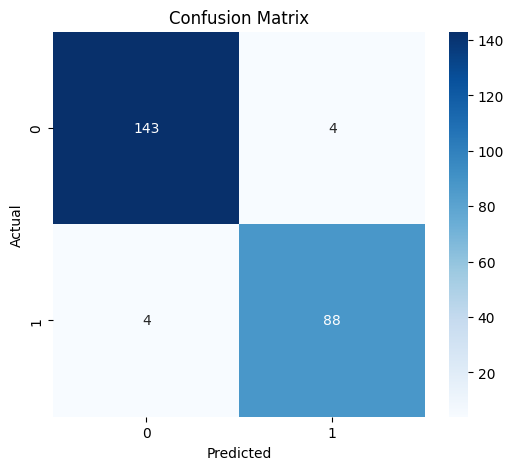

In [20]:
# Tính confusion matrix
cm = confusion_matrix(val_labels, val_labels_preds)

# Vẽ confusion matrix
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

**True Negatives (0,0)**: 143 mẫu thuộc lớp 0 được dự đoán đúng.

**False Positives (0,1)**: 4 mẫu lớp 0 bị dự đoán thành lớp 1. Điều này có thể do dữ liệu của lớp 0 có đặc trưng gần giống lớp 1, hoặc mô hình quá nhạy với các đặc trưng của lớp 1.

**False Negatives (1, 0)**: 4 mẫu lớp 1 bị dự đoán thành lớp 0. Có thể do dữ liệu lớp 1 không đủ đa dạng, hoặc mô hình thiếu khả năng phát hiện các đặc trưng đặc trưng của lớp 1 trong các mẫu này.

**True Positives (1,1)**: 88 mẫu thuộc lớp 1 được dự đoán đúng.




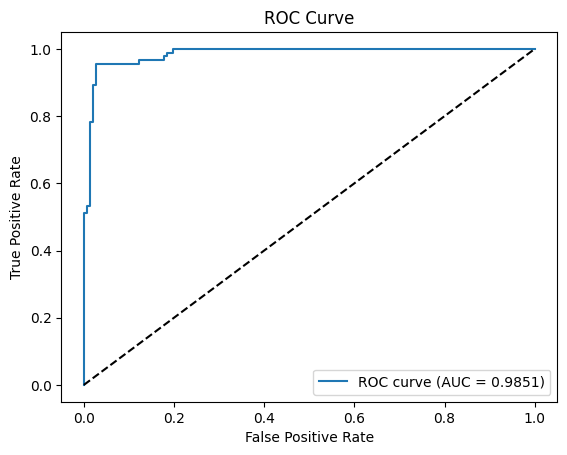

In [21]:
# Tính toán FPR và TPR cho đường cong ROC
fpr, tpr, _ = roc_curve(val_labels, val_prob_preds)

# Vẽ đường cong ROC
plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {auc_roc:.4f})')
plt.plot([0, 1], [0, 1], 'k--')  # Đường ngẫu nhiên
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()

Đường cong ROC gần sát góc trên bên trái, với AUC = 0.9851, xác nhận mô hình có khả năng phân biệt lớp rất tốt.
Đường cong nằm trên đường chéo (random guess), cho thấy hiệu suất vượt trội so với dự đoán ngẫu nhiên.

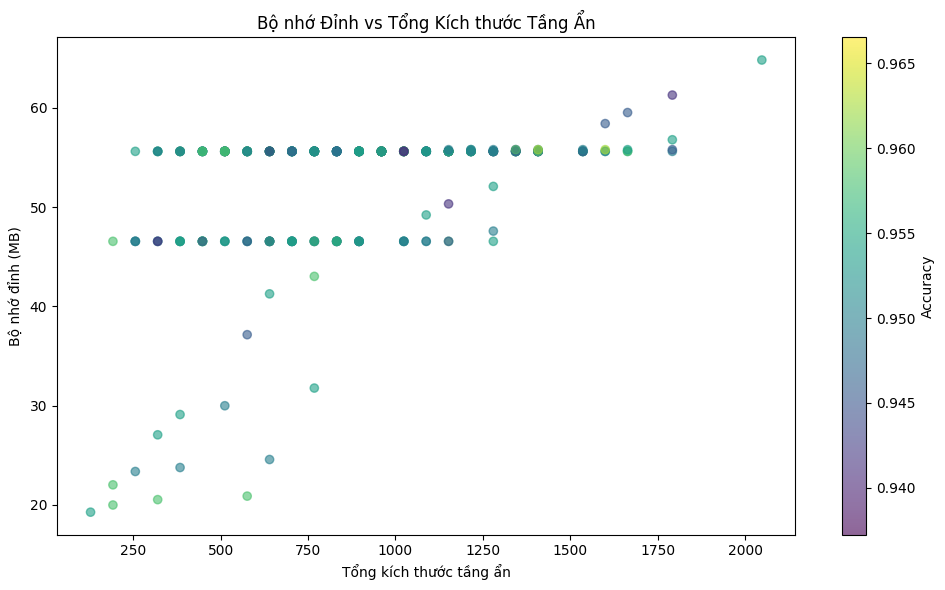

In [22]:
# Tính tổng kích thước tầng ẩn cho mỗi cấu hình
total_hidden_sizes = [sum(config['hidden_sizes']) for config in configs]  # Tổng số nơ-ron ẩn

plt.figure(figsize=(10, 6))
plt.scatter(total_hidden_sizes, peak_memories, c=best_acc_list, cmap='viridis', alpha=0.6)
plt.colorbar(label='Accuracy')
plt.xlabel('Tổng kích thước tầng ẩn')
plt.ylabel('Bộ nhớ đỉnh (MB)')
plt.title('Bộ nhớ Đỉnh vs Tổng Kích thước Tầng Ẩn')
plt.tight_layout()
plt.show()

Biểu đồ phân tán cho thấy:

Bộ nhớ đỉnh dao động từ ~20 MB đến ~65 MB, tăng dần khi tổng kích thước tầng ẩn tăng từ 250 đến 2000.

Accuracy dao động từ 0.940 đến 0.965, với các cấu hình có kích thước tầng ẩn lớn hơn thường đạt accuracy cao hơn (đặc biệt ở mức 0.965).

**Xu hướng**: Các cấu hình sử dụng nhiều bộ nhớ hơn (kích thước tầng ẩn lớn) có xu hướng đạt hiệu suất tốt hơn

## Dựa đoán trên tập test

In [23]:
with open('test.json', 'r') as f:
  test_data = json.load(f)


test_dataset = TestDataset(test_data, T_max)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

best_model.eval()
test_results = []
with torch.no_grad():
  for batch in test_loader:
    x, vid_ids = batch
    x = x.to(device)
    output = best_model(x)
    probs = torch.sigmoid(output).cpu().numpy().flatten()
    test_results.extend(zip(vid_ids, probs))

In [24]:
df = pd.DataFrame(test_results, columns=['vid_id', 'is_turkey'])
df.to_csv('22120071_22120078_22120182.csv', index=False)

In [25]:
print("vid_id,is_turkey")
for vid_id, prob in test_results:
    print(f"{vid_id},{prob:.4f}")

vid_id,is_turkey
pyKh38FXD3E,0.0024
THhP1idrWXA,0.0004
jsw3T6GY2Nw,0.0013
nFkXTMHcjMU,0.0001
Au8g9kAlrLQ,0.8464
tgk3DUpRI-w,0.0027
BczNwyCGlH4,0.0100
zB5eXpmJDTM,0.0007
099z8epFcfc,0.9993
lQ8DMnq415o,0.9994
GQiufwoajWs,1.0000
INo_-jgqN8k,0.9999
hYRPxAli0qQ,0.0009
3Gz_nevdXMw,0.9906
pRTdKKDW-eA,0.0004
Bea4YfWKAgY,0.0011
De-ZGbFCAes,0.9999
bWb7maOK2N4,0.0176
3yShrSi_g2I,0.0041
nUG2f3kzojI,0.9998
98MOYVfyKy4,0.0003
DntcoNVqEsQ,0.0033
t_acOLqB9ZA,0.0002
Di9E2EwpD_Y,0.9393
AMrMa379dY0,0.0018
phWfXmcDeRw,0.0009
AyACodY0hek,0.0002
U3YigFH5bMs,0.0012
sLHYvqfduwU,0.0007
xfGXhVboW9U,0.9999
GyjR5V0Sj94,0.0014
FcyOVSjbUEM,0.9986
NhKRCuCg0-g,0.9999
B_BlG6QhyCI,0.9485
CjPlMp0ToQc,0.9686
A5Ka8Yaonr8,0.0004
KJhk0LgrjeE,0.0003
heJYXuYA5Cc,0.9998
GFeMt2veznA,0.9999
mJo_u5KPNMM,0.0008
ZdnL9LMvJBw,0.0120
lrOISIMtHXg,0.0630
31apnEcdIQc,0.9991
sO0LPs5WtBo,0.7490
lqeHb_00T1A,0.0008
dPmqNGO-r44,0.9857
8hxuHS7nEwk,0.9981
TDNnNmgqhNI,0.9834
D-j1bgH3Wyg,0.0453
xvxZQDfQblA,0.4192
FDHIsDKSXlc,0.9996
i_ER8O87unM,1.